# Tiền xử lý FaceForensics++ C23 — Cache dùng chung cho 4 baseline + mô hình đề xuất

**Mục tiêu của notebook này:** trích khung hình, phát hiện & cắt khuôn mặt **một lần duy nhất**
cho toàn bộ tập FF++ C23 theo đúng file split chính thức (`train.json / val.json / test.json`),
lưu kết quả thành ảnh JPEG ra `/kaggle/working/ffpp_c23_cache/` — sau đó bạn **đóng gói thành
1 Kaggle Dataset riêng** để dùng lại vĩnh viễn cho:
- 4 baseline: Xception, SBI, UCF, Wu et al. (Spatial+rPPG)
- Mô hình đề xuất: DeepfakeFusionModel (Swin/ConvNeXt-Swin/CvT + rPPG + CAN)

**Trước khi chạy — thiết lập Kaggle Notebook:**
1. Settings → Accelerator → **GPU T4 x2** (cần GPU để chạy face detector nhanh)
2. Settings → Internet → **ON** (để tải pretrained weights của face detector)
3. Add Input → dataset FaceForensics++ C23 (đường dẫn mặc định trong notebook này là
   `/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/...` — đổi lại nếu bạn dùng dataset khác)
4. Upload 3 file `train.json`, `val.json`, `test.json` (file split chính thức của FF++) —
   có thể để trực tiếp trong `/kaggle/working/` (kéo-thả vào File Browser bên phải) hoặc
   add làm 1 Kaggle Dataset riêng rồi trỏ `SPLIT_JSON_DIR` tới đó.

**Kết quả cuối cùng bạn cần lưu vĩnh viễn:** thư mục `/kaggle/working/ffpp_c23_cache/`
(xem hướng dẫn đóng gói ở cell cuối notebook).

## 1. Cài đặt thư viện

In [1]:
!pip install -q facenet-pytorch --no-deps
print("Đã cài xong facenet-pytorch (MTCNN) mà không làm hỏng Numpy của Kaggle.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 25.9 MB/s eta 0:00:00
Đã cài xong facenet-pytorch (MTCNN) mà không làm hỏng Numpy của Kaggle.


## 2. Cấu hình (CONFIG) — chỉnh ở đây nếu đường dẫn khác

In [2]:
import os, json, cv2, glob, time, gc, shutil
import numpy as np
import pandas as pd
from pathlib import Path
import torch
import warnings
warnings.filterwarnings("ignore")

# ==================== ĐƯỜNG DẪN DATASET GỐC (theo đúng bạn cung cấp) ====================
FF_ROOT = "/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23"
REAL_DIR = os.path.join(FF_ROOT, "original")
FAKE_METHODS = ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]
FAKE_DIRS = {m: os.path.join(FF_ROOT, m) for m in FAKE_METHODS}

# ==================== FILE SPLIT CHÍNH THỨC (train.json/val.json/test.json) ====================
POSSIBLE_SPLIT_DIRS = [
    "/kaggle/input/datasets/peiyuanzhang/ff-split",   # <-- dataset split JSON của bạn
    "/kaggle/working",
    "/kaggle/input/ffpp-splits",
    "/kaggle/input/ff-splits",
    "/kaggle/input/ffpp-c23-splits",
]
SPLIT_JSON_DIR = None
for d in POSSIBLE_SPLIT_DIRS:
    if os.path.exists(os.path.join(d, "train.json")):
        SPLIT_JSON_DIR = d
        break
if SPLIT_JSON_DIR is None:
    raise FileNotFoundError(
        "Không tìm thấy train.json/val.json/test.json ở các vị trí mặc định.\n"
        "=> Hãy upload 3 file này vào /kaggle/working (kéo-thả trong File Browser) "
        "hoặc add làm Kaggle Dataset rồi thêm đường dẫn vào POSSIBLE_SPLIT_DIRS."
    )
print("Dùng file split từ:", SPLIT_JSON_DIR)

# ==================== NƠI LƯU CACHE ẢNH ĐÃ CROP ====================
OUT_DIR = "/kaggle/working/ffpp_c23_cache"
os.makedirs(OUT_DIR, exist_ok=True)

# ==================== THAM SỐ TRÍCH XUẤT (áp dụng đồng nhất cho mọi mô hình) ====================
NUM_FRAMES   = 32     # số khung hình/video, lấy cách đều nhau (chuẩn DeepfakeBench)
FACE_MARGIN  = 1.3    # hệ số phóng to bounding box quanh khuôn mặt
IMG_SIZE     = 256    # lưu ở độ phân giải cao; mỗi backbone downstream tự resize nhỏ hơn khi cần
JPEG_QUALITY = 92
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)
print("FF_ROOT tồn tại:", os.path.isdir(FF_ROOT))
print("OUT_DIR:", OUT_DIR)

Dùng file split từ: /kaggle/input/datasets/peiyuanzhang/ff-split
Device: cuda
FF_ROOT tồn tại: True
OUT_DIR: /kaggle/working/ffpp_c23_cache


## 3. Đọc file split & dựng danh sách video cần xử lý

**Quy tắc suy ra video từ mỗi cặp `[a, b]` trong file json** (đã kiểm chứng khớp đúng
720/140/140 real theo chuẩn FF++):
- 2 video **real**: `original/a.mp4` và `original/b.mp4`
- Với **mỗi trong 4 phương pháp fake**: 2 video fake theo **cả 2 chiều** —
  `{method}/a_b.mp4` **và** `{method}/b_a.mp4`

→ train.json (360 cặp) sinh ra 720 real + 2880 fake (720×4 phương pháp) — đúng chuẩn ngành.

In [3]:
def load_split(name):
    with open(os.path.join(SPLIT_JSON_DIR, f"{name}.json")) as f:
        return json.load(f)

splits = {s: load_split(s) for s in ["train", "val", "test"]}
for s, pairs in splits.items():
    ids = set()
    for a, b in pairs:
        ids.add(a); ids.add(b)
    print(f"{s:5s}: {len(pairs):4d} cặp  ->  {len(ids):4d} video real  ->  {len(ids)*4:4d} video fake/phương pháp")


def build_manifest(pairs, split_name):
    rows = []
    real_ids = set()
    for a, b in pairs:
        real_ids.add(a)
        real_ids.add(b)

    # ----- video REAL -----
    for rid in sorted(real_ids):
        rows.append({
            "split": split_name, "label": 0, "method": "original",
            "video_id": rid,
            "src_path": os.path.join(REAL_DIR, f"{rid}.mp4"),
        })

    # ----- video FAKE (cả 2 chiều, cho mỗi phương pháp) -----
    for a, b in pairs:
        for x, y in [(a, b), (b, a)]:
            fname = f"{x}_{y}.mp4"
            vid_id = f"{x}_{y}"
            for method in FAKE_METHODS:
                rows.append({
                    "split": split_name, "label": 1, "method": method,
                    "video_id": vid_id,
                    "src_path": os.path.join(FAKE_DIRS[method], fname),
                })
    return pd.DataFrame(rows)


manifest = pd.concat(
    [build_manifest(splits[s], s) for s in ["train", "val", "test"]],
    ignore_index=True,
)
print("\nTổng video cần xử lý (lý thuyết):", len(manifest))
print(manifest.groupby(["split", "method"])["video_id"].count())

train:  360 cặp  ->   720 video real  ->  2880 video fake/phương pháp
val  :   70 cặp  ->   140 video real  ->   560 video fake/phương pháp
test :   70 cặp  ->   140 video real  ->   560 video fake/phương pháp

Tổng video cần xử lý (lý thuyết): 5000
split  method        
test   Deepfakes         140
       Face2Face         140
       FaceSwap          140
       NeuralTextures    140
       original          140
train  Deepfakes         720
       Face2Face         720
       FaceSwap          720
       NeuralTextures    720
       original          720
val    Deepfakes         140
       Face2Face         140
       FaceSwap          140
       NeuralTextures    140
       original          140
Name: video_id, dtype: int64


## 4. Kiểm tra video thực sự tồn tại trên đĩa

Một số video có thể bị thiếu trong bản dataset bạn tải (lỗi khi upload/convert). Bước này
lọc ra danh sách thực tế xử lý được, đồng thời **ghi log số liệu thật** để báo cáo minh bạch
trong khóa luận/bài báo (ví dụ: "718/720 video real khả dụng").

In [4]:
manifest["exists"] = manifest["src_path"].apply(os.path.exists)
n_missing = (~manifest["exists"]).sum()
print(f"Số video KHÔNG tồn tại trên đĩa: {n_missing} / {len(manifest)}")

if n_missing > 0:
    print("\nVí dụ vài video bị thiếu:")
    print(manifest[~manifest["exists"]][["split", "method", "video_id"]].head(10))

manifest_full = manifest.copy()  # giữ lại bản đầy đủ để đối chiếu sau
manifest = manifest[manifest["exists"]].reset_index(drop=True)
manifest_full.to_csv(os.path.join(OUT_DIR, "manifest_theoretical.csv"), index=False)  # đầy đủ (cả video thiếu) để đối chiếu
manifest.to_csv(os.path.join(OUT_DIR, "manifest_actual.csv"), index=False)  # danh sách thực tế sẽ xử lý

print("\n=== Số video THỰC TẾ sẽ xử lý ===")
summary = manifest.groupby(["split", "label"])["video_id"].count().unstack(fill_value=0)
summary.columns = ["real", "fake"]
print(summary)

Số video KHÔNG tồn tại trên đĩa: 0 / 5000

=== Số video THỰC TẾ sẽ xử lý ===
       real  fake
split            
test    140   560
train   720  2880
val     140   560


## 5. Face detector (MTCNN) & hàm trích + cắt khuôn mặt

In [5]:
from facenet_pytorch import MTCNN

mtcnn = MTCNN(image_size=IMG_SIZE, margin=0, keep_all=False,
              post_process=False, select_largest=True, device=DEVICE)


def crop_face_frame(frame_rgb):
    """Phát hiện khuôn mặt + cắt theo margin; fallback center-crop nếu không detect được."""
    h, w = frame_rgb.shape[:2]
    try:
        boxes, probs = mtcnn.detect(frame_rgb)
    except Exception:
        boxes, probs = None, None

    if boxes is not None and len(boxes) > 0:
        idx = int(np.argmax(probs))
        x1, y1, x2, y2 = boxes[idx]
        bw, bh = x2 - x1, y2 - y1
        cx, cy = x1 + bw / 2, y1 + bh / 2
        half = max(bw, bh) * FACE_MARGIN / 2
        x1, y1 = int(max(cx - half, 0)), int(max(cy - half, 0))
        x2, y2 = int(min(cx + half, w)), int(min(cy + half, h))
    else:
        side = min(h, w)
        x1, y1 = (w - side) // 2, (h - side) // 2
        x2, y2 = x1 + side, y1 + side

    crop = frame_rgb[y1:y2, x1:x2]
    if crop.size == 0:
        side = min(h, w)
        x1, y1 = (w - side) // 2, (h - side) // 2
        crop = frame_rgb[y1:y1 + side, x1:x1 + side]
    return cv2.resize(crop, (IMG_SIZE, IMG_SIZE))


def extract_clip(video_path, out_dir, num_frames=NUM_FRAMES):
    """Trích num_frames khung hình cách đều nhau, cắt mặt, lưu JPEG."""
    os.makedirs(out_dir, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return 0

    idxs = np.linspace(0, max(total - 1, 0), num_frames).astype(int)
    idx_set = set(idxs.tolist())
    saved, cur = 0, 0
    while cur <= idxs[-1]:
        ret, frame = cap.read()
        if not ret:
            break
        if cur in idx_set:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            crop = crop_face_frame(frame_rgb)
            out_path = os.path.join(out_dir, f"frame_{saved:02d}.jpg")
            cv2.imwrite(out_path, cv2.cvtColor(crop, cv2.COLOR_RGB2BGR),
                        [int(cv2.IMWRITE_JPEG_QUALITY), JPEG_QUALITY])
            saved += 1
        cur += 1
    cap.release()
    return saved


def print_disk_usage(path="/kaggle/working"):
    total, used, free = shutil.disk_usage(path)
    print(f"    [Disk {path}] Used: {used/1e9:.2f} GB | Free: {free/1e9:.2f} GB")

## 6. Vòng lặp xử lý chính — tuần tự theo nhóm, có checkpoint/resume

**Nguyên tắc chống tràn bộ nhớ & mất tiến độ:**
- Xử lý **tuần tự từng nhóm** (`split` × `method`), không xử lý toàn bộ cùng lúc
- Ảnh crop lưu dạng **JPEG chất lượng 92** (nhẹ hơn PNG ~7-10 lần) → tổng dung lượng ước tính chỉ
  **~3-4 GB** cho toàn bộ 5518 video × 32 khung hình (thay vì ~26GB nếu dùng PNG)
- **Resumable**: nếu notebook bị ngắt (hết giờ session, mất kết nối...), chạy lại cell này —
  video nào đã có đủ 32 ảnh sẽ tự động **bỏ qua**, không xử lý lại từ đầu
- Sau mỗi nhóm, lưu checkpoint CSV ngay — không mất tiến độ nếu notebook crash giữa chừng

In [6]:
from tqdm import tqdm

CHECKPOINT_CSV = os.path.join(OUT_DIR, "manifest_processed.csv")


def process_group(df_group, group_name):
    results = []
    print(f"\n=== Xử lý nhóm: {group_name}  ({len(df_group)} video) ===")
    for i, row in enumerate(tqdm(df_group.itertuples(), total=len(df_group))):
        sub = "real" if row.label == 0 else f"fake_{row.method}"
        out_dir = os.path.join(OUT_DIR, row.split, sub, row.video_id)

        # ---- resume: bỏ qua nếu đã xử lý đủ frame trước đó ----
        if os.path.isdir(out_dir) and len(glob.glob(os.path.join(out_dir, "*.jpg"))) >= NUM_FRAMES:
            results.append(dict(video_id=row.video_id, split=row.split, label=row.label,
                                 method=row.method, out_dir=out_dir, n_frames=NUM_FRAMES,
                                 status="skip_exists"))
            continue

        try:
            n = extract_clip(row.src_path, out_dir, NUM_FRAMES)
            status = "ok" if n >= NUM_FRAMES * 0.8 else "partial"
        except Exception as e:
            n, status = 0, f"error: {e}"

        results.append(dict(video_id=row.video_id, split=row.split, label=row.label,
                             method=row.method, out_dir=out_dir, n_frames=n, status=status))

        if i % 200 == 0 and i > 0:
            print_disk_usage()
            gc.collect()

    return pd.DataFrame(results)


# Thứ tự xử lý: REAL trước (nhẹ, ít video), rồi lần lượt từng loại FAKE
groups = [(s, "original") for s in ["train", "val", "test"]]
for s in ["train", "val", "test"]:
    for m in FAKE_METHODS:
        groups.append((s, m))

all_results = []
# Nếu đã có checkpoint từ lần chạy trước, nạp lại để không mất tiến độ hiển thị (phần skip vẫn tự nhận qua out_dir)
if os.path.exists(CHECKPOINT_CSV):
    print("Tìm thấy checkpoint cũ, sẽ tiếp tục dựa trên các thư mục đã có sẵn.")

for split, method in groups:
    df_g = manifest[(manifest.split == split) & (manifest.method == method)]
    if len(df_g) == 0:
        continue
    res = process_group(df_g, f"{split}/{method}")
    all_results.append(res)
    pd.concat(all_results, ignore_index=True).to_csv(CHECKPOINT_CSV, index=False)
    print_disk_usage()

final_manifest = pd.concat(all_results, ignore_index=True)
final_manifest.to_csv(CHECKPOINT_CSV, index=False)

print("\n================ HOÀN TẤT TIỀN XỬ LÝ ================")
print(final_manifest["status"].value_counts())


=== Xử lý nhóm: train/original  (720 video) ===


 28%|██▊       | 201/720 [12:55<35:34,  4.11s/it]

    [Disk /kaggle/working] Used: 0.10 GB | Free: 20.84 GB


 56%|█████▌    | 401/720 [26:20<25:08,  4.73s/it]

    [Disk /kaggle/working] Used: 0.20 GB | Free: 20.74 GB


...

    [Disk /kaggle/working] Used: 2.27 GB | Free: 18.67 GB

=== Xử lý nhóm: test/FaceSwap  (140 video) ===


100%|██████████| 140/140 [08:47<00:00,  3.77s/it]


    [Disk /kaggle/working] Used: 2.34 GB | Free: 18.60 GB

=== Xử lý nhóm: test/NeuralTextures  (140 video) ===


100%|██████████| 140/140 [08:49<00:00,  3.78s/it]

    [Disk /kaggle/working] Used: 2.41 GB | Free: 18.54 GB

================ HOÀN TẤT TIỀN XỬ LÝ ================
status
ok    5000
Name: count, dtype: int64


## 7. Kiểm tra kết quả — số liệu thật, ảnh mẫu, tổng dung lượng

=== Số video xử lý THÀNH CÔNG theo split/label (0=real, 1=fake) ===
label    0     1
split           
test   140   560
train  720  2880
val    140   560

=== Chi tiết theo phương pháp fake ===
method  Deepfakes  Face2Face  FaceSwap  NeuralTextures
split                                                 
test          140        140       140             140
train         720        720       720             720
val           140        140       140             140


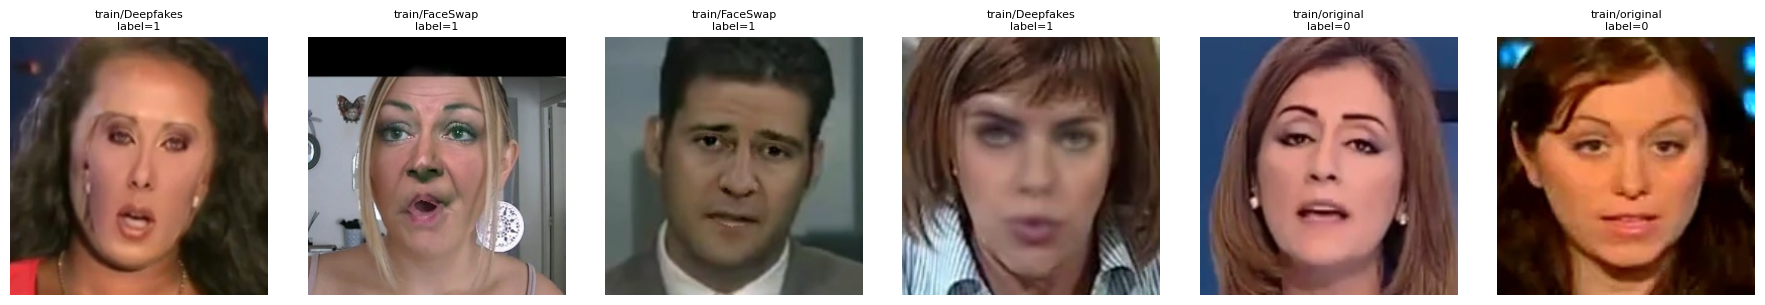


Tổng dung lượng cache đã lưu: 2.06 GB
Vị trí: /kaggle/working/ffpp_c23_cache


In [7]:
print("=== Số video xử lý THÀNH CÔNG theo split/label (0=real, 1=fake) ===")
ok_mask = final_manifest["status"].isin(["ok", "skip_exists"])
print(final_manifest[ok_mask].groupby(["split", "label"])["video_id"].count().unstack(fill_value=0))

print("\n=== Chi tiết theo phương pháp fake ===")
print(final_manifest[ok_mask & (final_manifest.label == 1)]
      .groupby(["split", "method"])["video_id"].count().unstack(fill_value=0))

# ---- ảnh mẫu ----
import matplotlib.pyplot as plt

n_ok = int(ok_mask.sum())
if n_ok == 0:
    print("\n⚠️  Không có video nào xử lý thành công -> bỏ qua bước hiển thị ảnh mẫu.")
else:
    sample_rows = final_manifest[ok_mask].sample(min(6, n_ok), random_state=42)
    fig, axes = plt.subplots(1, len(sample_rows), figsize=(3 * len(sample_rows), 3))
    if len(sample_rows) == 1:
        axes = [axes]
    for ax, row in zip(axes, sample_rows.itertuples()):
        imgs = sorted(glob.glob(os.path.join(row.out_dir, "*.jpg")))
        if imgs:
            img = cv2.cvtColor(cv2.imread(imgs[0]), cv2.COLOR_BGR2RGB)
            ax.imshow(img)
        ax.set_title(f"{row.split}/{row.method}\nlabel={row.label}", fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "sample_preview.png"), dpi=100)
    plt.show()

# ---- tổng dung lượng cache ----
def get_dir_size(path):
    total = 0
    for dirpath, _, filenames in os.walk(path):
        for fn in filenames:
            total += os.path.getsize(os.path.join(dirpath, fn))
    return total

size_gb = get_dir_size(OUT_DIR) / 1e9
print(f"\nTổng dung lượng cache đã lưu: {size_gb:.2f} GB")
print(f"Vị trí: {OUT_DIR}")

## 8. ⚠️ QUAN TRỌNG — Lưu cache VĨNH VIỄN (đọc kỹ trước khi đóng notebook)

`/kaggle/working/` **chỉ tồn tại tạm thời** — nếu bạn không lưu lại, toàn bộ ảnh vừa crop sẽ
**mất khi session kết thúc**. Làm theo đúng các bước sau để lưu vĩnh viễn:

### Bước 1 — Lưu version của notebook
Góc trên bên phải → **Save Version** → chọn **Save & Run All (Commit)** → đợi notebook chạy xong
toàn bộ từ đầu đến cuối (đảm bảo Internet=ON, GPU=ON như đã dặn ở đầu bài).

### Bước 2 — Tạo Kaggle Dataset từ output
Sau khi version chạy xong:
1. Vào tab **"Output"** của version vừa chạy (hoặc vào trang notebook → tab **Output**)
2. Bạn sẽ thấy toàn bộ thư mục `ffpp_c23_cache/` nằm trong output
3. Bấm **"New Dataset"** (hoặc "Create Dataset" tùy giao diện) từ chính output này
4. Đặt tên ví dụ: `ffpp-c23-face-cache` → **Create**

→ Kết quả: bạn có **1 Kaggle Dataset riêng, tồn tại vĩnh viễn**, chứa toàn bộ ảnh khuôn mặt
đã crop, đường dẫn dạng: `/kaggle/input/ffpp-c23-face-cache/ffpp_c23_cache/...`

### Bước 3 — Dùng lại cho các notebook train baseline/mô hình đề xuất
Trong MỌI notebook train sau này (Xception, SBI, UCF, Wu et al., DeepfakeFusionModel):
1. Add Input → chọn dataset `ffpp-c23-face-cache` vừa tạo
2. Đọc trực tiếp ảnh + file `manifest_processed.csv` (đã có sẵn nhãn `label`, `split`, `method`)
   để dựng PyTorch `Dataset`/`DataLoader` — **không cần crop lại**

### Cấu trúc thư mục cache cuối cùng
```
ffpp_c23_cache/
├── manifest_processed.csv      # danh sách đầy đủ: video_id, split, label, method, out_dir, status
├── manifest_theoretical.csv    # danh sách lý thuyết trước khi lọc video thiếu
├── sample_preview.png
├── train/
│   ├── real/{video_id}/frame_00.jpg ... frame_31.jpg
│   ├── fake_Deepfakes/{video_id}/...
│   ├── fake_Face2Face/{video_id}/...
│   ├── fake_FaceSwap/{video_id}/...
│   └── fake_NeuralTextures/{video_id}/...
├── val/        (cấu trúc tương tự train/)
└── test/       (cấu trúc tương tự train/)
```

**Lưu ý:** Nếu bạn cần chuẩn bị thêm tập test cross-dataset Celeb-DF v2, dùng lại đúng 2 hàm
`crop_face_frame()` và `extract_clip()` ở Mục 5 cho các video Celeb-DF (cùng `IMG_SIZE`,
`NUM_FRAMES`, `FACE_MARGIN`) để đảm bảo pipeline tiền xử lý đồng nhất giữa intra-dataset và
cross-dataset — nên làm trong 1 notebook riêng để không lẫn với phần FF++ này.